Empty DataFrame
Columns: [edad, edad2]
Index: []


ValueError: cannot convert float NaN to integer

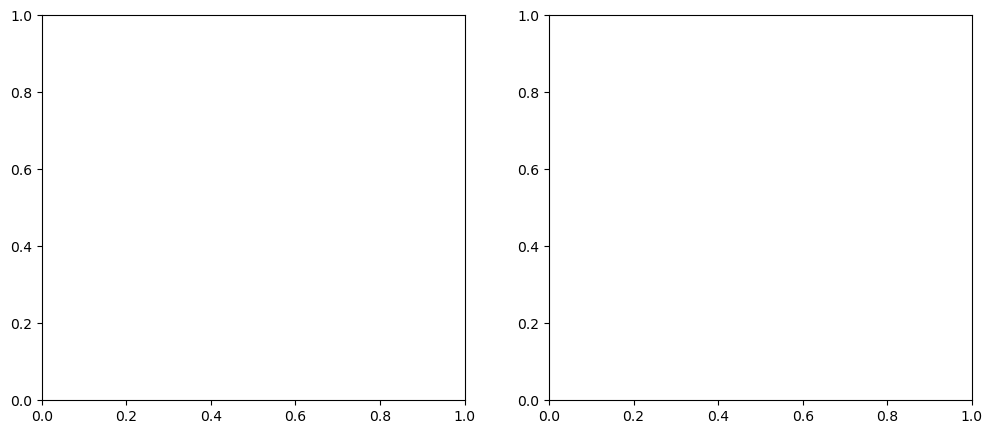

In [9]:
#PARTE 1-1
# en este paso importo librerías
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# en este paso fijo carpeta y archivo
PATH_BASES = Path.cwd()
file_resp = PATH_BASES / "respondieron.xlsx"

# en este paso cargo la base
df = pd.read_excel(file_resp, dtype="object")

# en este paso tipifico variables usadas
df["edad"] = pd.to_numeric(df.get("edad"), errors="coerce")
df["pobre"] = pd.to_numeric(df.get("pobre"), errors="coerce")

# en este paso creo edad2 = edad al cuadrado
df = df[df["edad"].notna()].copy()
df["edad2"] = df["edad"] ** 2

# en este paso verifico la nueva variable
print(df[["edad", "edad2"]].head())

# en este paso preparo los datos para kernels
pobres = df[df["pobre"] == 1]["edad"].dropna()
no_pobres = df[df["pobre"] == 0]["edad"].dropna()

# en este paso grafico paneles A y B
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel A: histograma de edad
bins_ = np.arange(0, int(df["edad"].max()) + 5, 5)
axes[0].hist(df["edad"].dropna(), bins=bins_, alpha=0.7, color="steelblue")
axes[0].set_title("Panel A. Histograma de edad")
axes[0].set_xlabel("Edad")
axes[0].set_ylabel("Frecuencia")
axes[0].set_xlim(0, 100)

# Panel B: kernels de edad por condición de pobreza
sns.kdeplot(pobres, ax=axes[1], label="Pobres", clip=(0, 100))
sns.kdeplot(no_pobres, ax=axes[1], label="No pobres", clip=(0, 100))
axes[1].set_title("Panel B. Densidad Kernel de edad")
axes[1].set_xlabel("EDAD")
axes[1].set_ylabel("Densidad")
axes[1].legend()
axes[1].set_xlim(0, 100)

plt.tight_layout()
plt.show()

# en este paso guardo la base actualizada
df.to_excel(file_resp, index=False)



In [7]:
#PARTE 1-2
# en este paso importo librerías
import pandas as pd
import numpy as np
from pathlib import Path

# en este paso fijo carpeta y archivo
PATH_BASES = Path.cwd()
file_resp = PATH_BASES / "respondieron.xlsx"

# en este paso cargo la base
df = pd.read_excel(file_resp, dtype="object")

# en este paso detecto la columna de nivel educativo
candidatas = ["nivel_educ"]
nivel_col = next((c for c in candidatas if c in df.columns), None)
if nivel_col is None:
    raise ValueError("No encuentro la columna de nivel educativo en respondieron.xlsx")

# en este paso tipifico la variable educativa
df[nivel_col] = pd.to_numeric(df[nivel_col], errors="coerce")

# en este paso defino el mapeo a años de educación según tus reglas
#  primario completo=6, secundario completo=12 total, universitario completo=17 total
#  incompletos=mitad del completo, sin instrucción=0, posgrado completo=+2 (19)
map_educ = {
    7: 0,   # sin instrucción
    1: 3,   # primario incompleto
    2: 6,   # primario completo
    3: 9,   # secundario incompleto
    4: 12,  # secundario completo
    5: 15,  # superior/universitario incompleto
    6: 17,  # superior/universitario completo
    8: 19   # posgrado universitario completo
}

# en este paso creo la variable educ
df["educ"] = df[nivel_col].map(map_educ).astype("float")

# en este paso muestro chequeo rápido
print("Columna educativa usada:", nivel_col)
print("Valores no mapeados:", sorted(v for v in df[nivel_col].dropna().unique() if v not in map_educ))

# en este paso guardo la base actualizada
df.to_excel(file_resp, index=False)

print("Listo, agregué 'educ' a respondieron.xlsx")

# en este paso calculo estadísticos descriptivos de años de educación
stats = df["educ"].agg(["mean", "std", "min", "median", "max"]).rename({
    "mean": "promedio",
    "std": "desvío_std",
    "min": "mínimo",
    "median": "p50",
    "max": "máximo"
})

# en este paso muestro resultados
print("Estadísticas descriptivas de años de educación:")
print(stats)

# en este paso guardo tabla en Excel
out = pd.DataFrame(stats).T
out.to_excel(PATH_BASES / "estadisticas_educParte1-2.xlsx", index=False)



ValueError: No encuentro la columna de nivel educativo en respondieron.xlsx

In [10]:
#PARTE 1-3
# en este paso importo librerías
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# en este paso fijo carpeta y archivo
PATH_BASES = Path.cwd()
file_resp = PATH_BASES / "respondieron.xlsx"

# en este paso cargo la base
df = pd.read_excel(file_resp)

# en este paso tipifico variables clave
df["anio"] = pd.to_numeric(df.get("anio"), errors="coerce")
df["ITF"] = pd.to_numeric(df.get("ITF"), errors="coerce")
df["pobre"] = pd.to_numeric(df.get("pobre"), errors="coerce")

# en este paso creo variable itfipc (ITF ajustado a precios 2025)
factor_inflacion = 1 + 94803.91 / 100
df["itfipc"] = np.where(df["anio"] == 2005, df["ITF"] * factor_inflacion, df["ITF"])

# en este paso calculo línea de pobreza implícita según variable pobre
# uso el máximo ingreso entre pobres como umbral
linea_pobreza = df.loc[df["pobre"] == 1, "ingreso_total_familiar"].max()

# en este paso preparo datos para kernel
pobres = df.loc[df["pobre"] == 1, "ingreso_total_familiar"].dropna()
no_pobres = df.loc[df["pobre"] == 0, "ingreso_total_familiar"].dropna()

# en este paso grafico paneles A y B
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel A: histograma de ingreso_total_familiar
axes[0].hist(df["ingreso_total_familiar"].dropna(), bins=50, color="steelblue", alpha=0.7)
axes[0].axvline(linea_pobreza, color="red", linestyle="--", label="Línea de pobreza")
axes[0].set_title("Panel A. Histograma de ingreso total familiar")
axes[0].set_xlabel("Ingreso total familiar (pesos 2025)")
axes[0].set_ylabel("Frecuencia")
axes[0].legend()

# Panel B: densidad kernel por condición de pobreza
sns.kdeplot(pobres, ax=axes[1], label="Pobres")
sns.kdeplot(no_pobres, ax=axes[1], label="No pobres")
axes[1].axvline(linea_pobreza, color="red", linestyle="--", label="Línea de pobreza")
axes[1].set_title("Panel B. Densidad kernel de ingreso total familiar")
axes[1].set_xlabel("Ingreso total familiar (pesos 2025)")
axes[1].set_ylabel("Densidad")
axes[1].legend()

plt.tight_layout()
plt.show()

# en este paso guardo la base actualizada
df.to_excel(file_resp, index=False)

print("Listo, se creó 'itfipc', se actualizó ingreso_total_familiar y se graficaron los paneles.")


KeyError: 'ingreso_total_familiar'